# 02 — Data Cleaning

1. Validar reglas lógicas en **pandas** (sobre el sample del EDA)
2. Traducir cada regla a **SQL** y ejecutarla en Snowflake (Pushdown)

**Entrada:** sample de `ANALYTICS.TRAIN_SET`  
**Salida:** `ANALYTICS.TRAIN_CLEAN`, `ANALYTICS.VAL_CLEAN`, `ANALYTICS.TEST_CLEAN`

> Nunca cargamos los datasets completos. Todas las reglas de limpieza se aplican del lado de Snowflake una vez validadas en el sample.

## Imports y conexión

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector
import warnings

warnings.filterwarnings('ignore')
load_dotenv()
sns.set_theme(style='whitegrid')

def get_conn():
    return snowflake.connector.connect(
        account   = os.environ['SNOWFLAKE_ACCOUNT'],
        user      = os.environ['SNOWFLAKE_USER'],
        password  = os.environ['SNOWFLAKE_PASSWORD'],
        database  = os.environ['SNOWFLAKE_DATABASE'],
        warehouse = os.environ['SNOWFLAKE_WAREHOUSE'],
        schema    = os.environ['SNOWFLAKE_SCHEMA'],
        role      = os.environ.get('SNOWFLAKE_ROLE'),
    )

def query(sql: str) -> pd.DataFrame:
    conn = get_conn()
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

def execute(sql: str):
    """Ejecuta DDL/DML sin retornar datos."""
    conn = get_conn()
    try:
        cur = conn.cursor()
        cur.execute(sql)
        conn.commit()
        print(f'OK: {cur.rowcount} filas afectadas' if cur.rowcount >= 0 else 'OK')
    finally:
        conn.close()

print('Conexión lista.')

Conexión lista.


## 1. Carga del sample 

Usamos el mismo 1% de `TRAIN_SET` para desarrollar y validar todas las reglas.

In [3]:
df = query("""
    SELECT *
    FROM ANALYTICS.TRAIN_SET
    TABLESAMPLE (1)
""")

print(f'Filas en muestra: {len(df):,}')
print(f'Columnas        : {df.shape[1]}')
df.dtypes

Filas en muestra: 7,695,007
Columnas        : 44


SERVICE_TYPE                     object
VENDOR_ID                         int64
VENDOR_NAME                      object
PICKUP_DATETIME          datetime64[ns]
DROPOFF_DATETIME         datetime64[ns]
PICKUP_DATE                      object
PICKUP_HOUR                       int64
DAY_OF_WEEK                       int64
MONTH                             int64
YEAR                              int64
DROPOFF_DATE                     object
DROPOFF_HOUR                      int64
PU_LOCATION_ID                    int64
PU_ZONE                          object
PU_BOROUGH                       object
DO_LOCATION_ID                    int64
DO_ZONE                          object
DO_BOROUGH                       object
RATE_CODE_ID                      int64
RATE_CODE_DESC                   object
PAYMENT_TYPE                      int64
PAYMENT_TYPE_DESC                object
TRIP_TYPE                       float64
PASSENGER_COUNT                   int64
TRIP_DISTANCE                   float64


## 2. Regla 1 — Nulos en columnas obligatorias

**Lógica:** Un viaje sin pickup_datetime, ubicación o monto no es usable para entrenamiento.

In [4]:

OBLIGATORIAS = [
    'PICKUP_DATETIME', 'PU_LOCATION_ID', 'DO_LOCATION_ID',
    'FARE_AMOUNT', 'TRIP_DISTANCE', 'PASSENGER_COUNT', 'SERVICE_TYPE'
]

nulos_antes = len(df)
mask_nulos = df[OBLIGATORIAS].isnull().any(axis=1)
nulos_count = mask_nulos.sum()

print(f'Filas con nulos en columnas obligatorias: {nulos_count:,} ({nulos_count/nulos_antes*100:.2f}%)')
print('\nDesglose por columna:')
print(df[OBLIGATORIAS].isnull().sum().to_string())

# Aplicar filtro en pandas
df_clean = df[~mask_nulos].copy()
print(f'\nFilas restantes tras eliminar nulos: {len(df_clean):,}')

Filas con nulos en columnas obligatorias: 0 (0.00%)

Desglose por columna:
PICKUP_DATETIME    0
PU_LOCATION_ID     0
DO_LOCATION_ID     0
FARE_AMOUNT        0
TRIP_DISTANCE      0
PASSENGER_COUNT    0
SERVICE_TYPE       0

Filas restantes tras eliminar nulos: 7,695,007


## 3. Regla 2 — Timestamp lógico (pickup ≤ dropoff)

In [5]:

df_clean['PICKUP_DATETIME'] = pd.to_datetime(df_clean['PICKUP_DATETIME'])
df_clean['DROPOFF_DATETIME'] = pd.to_datetime(df_clean['DROPOFF_DATETIME'])

mask_ts = df_clean['PICKUP_DATETIME'] > df_clean['DROPOFF_DATETIME']
print(f'Viajes con pickup > dropoff: {mask_ts.sum():,} ({mask_ts.mean()*100:.3f}%)')

df_clean = df_clean[~mask_ts]
print(f'Filas restantes: {len(df_clean):,}')

Viajes con pickup > dropoff: 0 (0.000%)
Filas restantes: 7,695,007


## 4. Regla 3 — Rangos lógicos del target: FARE_AMOUNT

Viajes fuera del rango de FARE_AMOUNT [2.5, 300.0]:
  Total: 5,183 (0.07%)
  Fare < 2.5 : 4,980
  Fare > 300.0 : 203


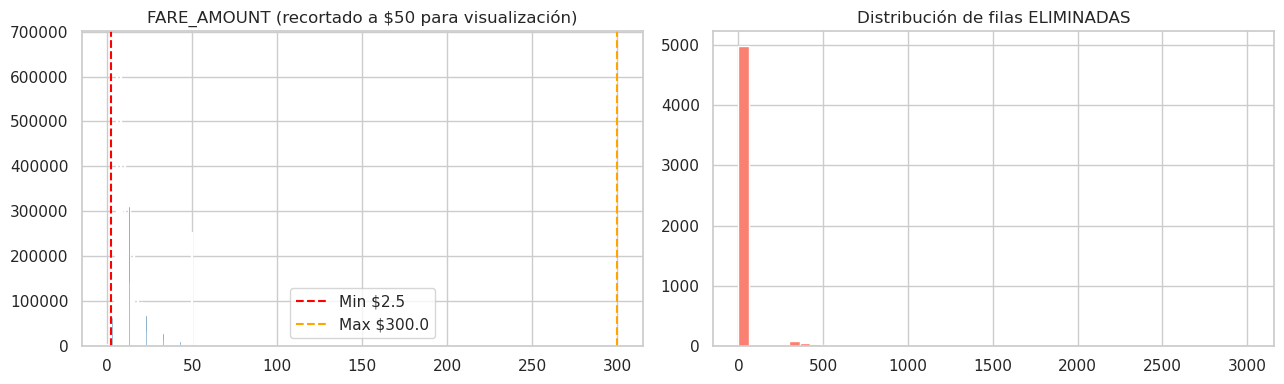

Filas restantes: 7,689,824


In [6]:
# Tarifa mínima NYC TLC = $2.50. Máximo razonable = $300 (vuelos privados aparte)
FARE_MIN = 2.50
FARE_MAX = 300.0

mask_fare = ~df_clean['FARE_AMOUNT'].between(FARE_MIN, FARE_MAX)
print(f'Viajes fuera del rango de FARE_AMOUNT [{FARE_MIN}, {FARE_MAX}]:')
print(f'  Total: {mask_fare.sum():,} ({mask_fare.mean()*100:.2f}%)')
print(f'  Fare < {FARE_MIN} : {(df_clean["FARE_AMOUNT"] < FARE_MIN).sum():,}')
print(f'  Fare > {FARE_MAX} : {(df_clean["FARE_AMOUNT"] > FARE_MAX).sum():,}')

# Visualizar la zona eliminada
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_clean['FARE_AMOUNT'].clip(0, 50).hist(bins=80, ax=axes[0], color='steelblue')
axes[0].axvline(FARE_MIN, color='red',   linestyle='--', label=f'Min ${FARE_MIN}')
axes[0].axvline(FARE_MAX, color='orange',linestyle='--', label=f'Max ${FARE_MAX}')
axes[0].set_title('FARE_AMOUNT (recortado a $50 para visualización)')
axes[0].legend()

df_clean[mask_fare]['FARE_AMOUNT'].hist(bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de filas ELIMINADAS')
plt.tight_layout()
plt.show()

df_clean = df_clean[~mask_fare]
print(f'Filas restantes: {len(df_clean):,}')

## 5. Regla 4 — Rangos lógicos: TRIP_DISTANCE y PASSENGER_COUNT

In [7]:

DIST_MIN = 0.1    # millas — viajes menores son probablemente errores
DIST_MAX = 150.0  # millas — límite razonable para NYC/área metropolitana
PAX_MIN = 1
PAX_MAX = 6      # máximo oficial TLC para taxis estándar

mask_dist = ~df_clean['TRIP_DISTANCE'].between(DIST_MIN, DIST_MAX)
mask_pax = ~df_clean['PASSENGER_COUNT'].between(PAX_MIN, PAX_MAX)

print(f'Viajes fuera de rango TRIP_DISTANCE [{DIST_MIN}, {DIST_MAX}]: '
      f'{mask_dist.sum():,} ({mask_dist.mean()*100:.2f}%)')
print(f'Viajes fuera de rango PASSENGER_COUNT [{PAX_MIN}, {PAX_MAX}]: '
      f'{mask_pax.sum():,} ({mask_pax.mean()*100:.2f}%)')

df_clean = df_clean[~mask_dist & ~mask_pax]
print(f'Filas restantes: {len(df_clean):,}')

Viajes fuera de rango TRIP_DISTANCE [0.1, 150.0]: 75,893 (0.99%)
Viajes fuera de rango PASSENGER_COUNT [1, 6]: 52,710 (0.69%)
Filas restantes: 7,562,703


## 6. Regla 5 — Consistencia: RATE_CODE_ID válido

In [8]:

# Rate codes válidos según NYC TLC: 1-6 y 99
VALID_RATE_CODES = {1, 2, 3, 4, 5, 6, 99}

mask_rate = ~df_clean['RATE_CODE_ID'].isin(VALID_RATE_CODES) & df_clean['RATE_CODE_ID'].notna()
print(f'Viajes con RATE_CODE_ID inválido: {mask_rate.sum():,} ({mask_rate.mean()*100:.3f}%)')
print('Valores encontrados fuera del catálogo:')
print(df_clean.loc[mask_rate, 'RATE_CODE_ID'].value_counts().to_string())

df_clean = df_clean[~mask_rate]
print(f'Filas restantes: {len(df_clean):,}')

Viajes con RATE_CODE_ID inválido: 0 (0.000%)
Valores encontrados fuera del catálogo:
Series([], )
Filas restantes: 7,562,703


## 7. Resumen del impacto de la limpieza en el sample

Filas originales :  7,695,007
Filas limpias :  7,562,703
Filas eliminadas :    132,304  (1.72%)


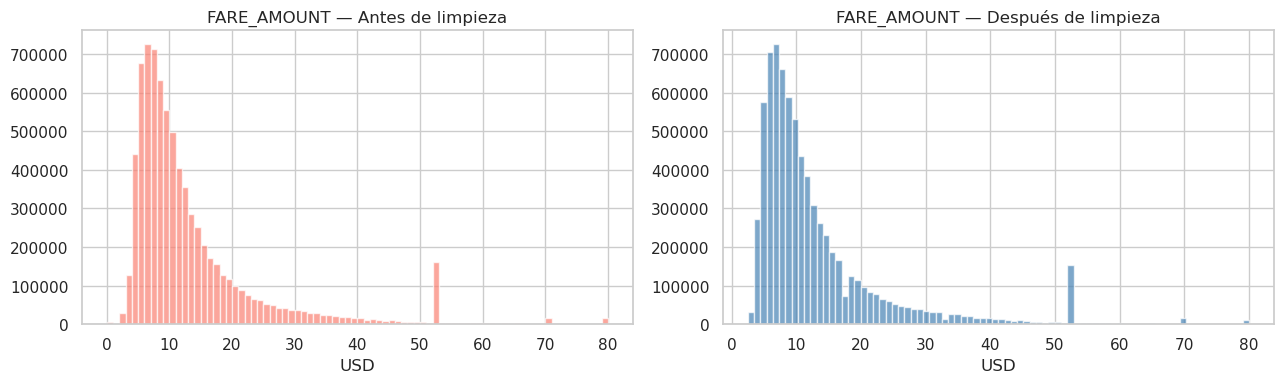


Estadísticas FARE_AMOUNT antes vs después:
            Antes     Después
count  7695007.00  7562703.00
mean        13.36       13.28
std         12.03       11.41
min          0.00        2.50
25%          6.50        6.50
50%          9.50        9.50
75%         15.00       15.00
max       3008.50      300.00


In [9]:
filas_originales = len(df)
filas_limpias = len(df_clean)
pct_eliminadas = (filas_originales - filas_limpias) / filas_originales * 100

print(f'Filas originales : {filas_originales:>10,}')
print(f'Filas limpias : {filas_limpias:>10,}')
print(f'Filas eliminadas : {filas_originales - filas_limpias:>10,}  ({pct_eliminadas:.2f}%)')

# Comparar distribución del target antes y después
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['FARE_AMOUNT'].clip(0, 80).hist(bins=80, ax=axes[0], color='salmon',   alpha=0.7, label='Original')
df_clean['FARE_AMOUNT'].clip(0, 80).hist(bins=80, ax=axes[1], color='steelblue', alpha=0.7, label='Limpio')
axes[0].set_title('FARE_AMOUNT — Antes de limpieza')
axes[1].set_title('FARE_AMOUNT — Después de limpieza')
for ax in axes:
    ax.set_xlabel('USD')
plt.tight_layout()
plt.show()

print('\nEstadísticas FARE_AMOUNT antes vs después:')
comp = pd.DataFrame({
    'Antes': df['FARE_AMOUNT'].describe(),
    'Después': df_clean['FARE_AMOUNT'].describe()
}).round(2)
print(comp.to_string())


## 8. Traducción a SQL — Pushdown a Snowflake

Cada regla validada en pandas arriba se traduce aquí a SQL.  
Creamos tres tablas limpias: `TRAIN_CLEAN`, `VAL_CLEAN`, `TEST_CLEAN`.

> El split `TEST_CLEAN` se crea ahora pero **no se toca** hasta la evaluación final.

In [10]:
# Bloque SQL reutilizable con todas las reglas de limpieza
# Se parametriza con {SOURCE_TABLE} y {TARGET_TABLE}

CLEANING_SQL = """
CREATE OR REPLACE TABLE ANALYTICS.{TARGET_TABLE} AS
SELECT *
FROM   ANALYTICS.{SOURCE_TABLE}
WHERE
    -- Regla 1: Nulos en columnas obligatorias
    PICKUP_DATETIME  IS NOT NULL
    AND PU_LOCATION_ID   IS NOT NULL
    AND DO_LOCATION_ID   IS NOT NULL
    AND FARE_AMOUNT      IS NOT NULL
    AND TRIP_DISTANCE    IS NOT NULL
    AND PASSENGER_COUNT  IS NOT NULL
    AND SERVICE_TYPE     IS NOT NULL

    -- Regla 2: Timestamp lógico
    AND PICKUP_DATETIME <= DROPOFF_DATETIME

    -- Regla 3: Rango de FARE_AMOUNT (tarifa mínima NYC TLC = $2.50)
    AND FARE_AMOUNT BETWEEN 2.50 AND 300.0

    -- Regla 4: Rango de TRIP_DISTANCE y PASSENGER_COUNT
    AND TRIP_DISTANCE   BETWEEN 0.1 AND 150.0
    AND PASSENGER_COUNT BETWEEN 1   AND 6

    -- Regla 5: RATE_CODE_ID en catálogo válido TLC
    AND (RATE_CODE_ID IN (1, 2, 3, 4, 5, 6, 99) OR RATE_CODE_ID IS NULL)
;
"""

print('SQL de limpieza definido. Listo para aplicar a cada split.')

SQL de limpieza definido. Listo para aplicar a cada split.


In [15]:
# Aplicar a TRAIN_SET lo de TRAIN_CLEAN
print('Creando TRAIN_CLEAN...')
execute(CLEANING_SQL.format(SOURCE_TABLE='TRAIN_SET', TARGET_TABLE='TRAIN_CLEAN'))

df_verify = query("SELECT COUNT(*) AS FILAS FROM ANALYTICS.TRAIN_CLEAN")
print(f'TRAIN_CLEAN filas: {df_verify["FILAS"][0]:,}')

Creando TRAIN_CLEAN...
OK: 1 filas afectadas
TRAIN_CLEAN filas: 756,082,886


In [16]:
# Aplicar a VAL_SET lo de VAL_CLEAN
print('Creando VAL_CLEAN...')
execute(CLEANING_SQL.format(SOURCE_TABLE='VAL_SET', TARGET_TABLE='VAL_CLEAN'))

df_verify = query("SELECT COUNT(*) AS FILAS FROM ANALYTICS.VAL_CLEAN")
print(f'VAL_CLEAN filas: {df_verify["FILAS"][0]:,}')

Creando VAL_CLEAN...
OK: 1 filas afectadas
VAL_CLEAN filas: 36,092,486


In [17]:
# Aplicar a TEST_SET lo de TEST_CLEAN
print('Creando TEST_CLEAN...')
execute(CLEANING_SQL.format(SOURCE_TABLE='TEST_SET', TARGET_TABLE='TEST_CLEAN'))

df_verify = query("SELECT COUNT(*) AS FILAS FROM ANALYTICS.TEST_CLEAN")
print(f'TEST_CLEAN filas: {df_verify["FILAS"][0]:,}')

Creando TEST_CLEAN...
OK: 1 filas afectadas
TEST_CLEAN filas: 35,972,142


## 9. Verificación final: impacto de limpieza en cada split

In [18]:
df_impact = query("""
    SELECT 'TRAIN' AS SPLIT,
        (SELECT COUNT(*) FROM ANALYTICS.TRAIN_SET)   AS ORIGINAL,
        (SELECT COUNT(*) FROM ANALYTICS.TRAIN_CLEAN) AS LIMPIO
    UNION ALL
    SELECT 'VAL',
        (SELECT COUNT(*) FROM ANALYTICS.VAL_SET),
        (SELECT COUNT(*) FROM ANALYTICS.VAL_CLEAN)
    UNION ALL
    SELECT 'TEST',
        (SELECT COUNT(*) FROM ANALYTICS.TEST_SET),
        (SELECT COUNT(*) FROM ANALYTICS.TEST_CLEAN)
""")

df_impact['ELIMINADAS'] = df_impact['ORIGINAL'] - df_impact['LIMPIO']
df_impact['PCT_ELIMINADAS'] = (df_impact['ELIMINADAS'] / df_impact['ORIGINAL'] * 100).round(2)
print(df_impact.to_string(index=False))

SPLIT  ORIGINAL    LIMPIO  ELIMINADAS  PCT_ELIMINADAS
TRAIN 769225608 756082886    13142722            1.71
  VAL  37092225  36092486      999739            2.70
 TEST  36833250  35972142      861108            2.34


In [19]:
# Verificar que no hay leakage temporal en los splits limpios
# Cada split debe tener exactamente su rango de años
df_years = query("""
    SELECT 'TRAIN_CLEAN' AS SPLIT, MIN(YEAR) AS MIN_YEAR, MAX(YEAR) AS MAX_YEAR
    FROM ANALYTICS.TRAIN_CLEAN
    UNION ALL
    SELECT 'VAL_CLEAN',   MIN(YEAR), MAX(YEAR) FROM ANALYTICS.VAL_CLEAN
    UNION ALL
    SELECT 'TEST_CLEAN',  MIN(YEAR), MAX(YEAR) FROM ANALYTICS.TEST_CLEAN
""")

print('Rango de años por split (debe ser: TRAIN=2015-2023, VAL=2024, TEST=2025):')
print(df_years.to_string(index=False))

Rango de años por split (debe ser: TRAIN=2015-2023, VAL=2024, TEST=2025):
      SPLIT  MIN_YEAR  MAX_YEAR
TRAIN_CLEAN      2015      2023
  VAL_CLEAN      2024      2024
 TEST_CLEAN      2025      2025


In [20]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           RESUMEN CLEANING — REGLAS APLICADAS                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Regla 1: Eliminar nulos en columnas obligatorias                ║
║           (PICKUP_DATETIME, PU/DO_LOCATION_ID,                   ║
║            FARE_AMOUNT, TRIP_DISTANCE, PASSENGER_COUNT)          ║
║                                                                  ║
║  Regla 2: Pickup <= Dropoff (timestamps coherentes)              ║
║                                                                  ║
║  Regla 3: FARE_AMOUNT ∈ [2.50, 300.0]                           ║
║           (tarifa mínima NYC TLC / máximo razonable)             ║
║                                                                  ║
║  Regla 4: TRIP_DISTANCE ∈ [0.1, 150.0] millas                   ║
║           PASSENGER_COUNT ∈ [1, 6]                               ║
║                                                                  ║
║  Regla 5: RATE_CODE_ID en {1,2,3,4,5,6,99} o NULL               ║
║                                                                  ║
║  Todas las reglas aplicadas en Snowflake (Pushdown).             ║
║  TRAIN/VAL/TEST_CLEAN listas para feature engineering.           ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           RESUMEN CLEANING — REGLAS APLICADAS                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Regla 1: Eliminar nulos en columnas obligatorias                ║
║           (PICKUP_DATETIME, PU/DO_LOCATION_ID,                   ║
║            FARE_AMOUNT, TRIP_DISTANCE, PASSENGER_COUNT)          ║
║                                                                  ║
║  Regla 2: Pickup <= Dropoff (timestamps coherentes)              ║
║                                                                  ║
║  Regla 3: FARE_AMOUNT ∈ [2.50, 300.0]                           ║
║           (tarifa mínima NYC TLC / máximo razonable)             ║
║                                                                  ║
║  Regla 4: TRIP_DISTANCE ∈ [0.1, 150.0] millas                   ║
║           PASSENGER_COUNT ∈ [1, 6]